In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import os  
#Required to Load inbuilt data set from sklearn
from sklearn.datasets import load_breast_cancer 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#Model to be used
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score, 
                             recall_score, f1_score, matthews_corrcoef, confusion_matrix)

In [2]:
# 1. Load Data form skelearn and perform EDA
data = load_breast_cancer()

#type of sklearn data
print(type(data), end="\n\n")

# view the keys the data
print(data.keys(), end="\n\n")

#  Convert to DataFrame for EDA 
# get all features
df = pd.DataFrame(data.data, columns=data.feature_names)
#get target
df['target'] = data.target

# check data for EDA like type and any missing values 
print(f"shape of the data set is : {df.shape}", end="\n\n")
print(df.info(), end="\n\n")
print(df.head(), end="\n\n")

#print(df.describe())

X = pd.DataFrame(df, columns=data.feature_names)
y = pd.Series(df.target) # Note: In this dataset, 0 = Malignant (Cancer), 1 = Benign (Safe).


<class 'sklearn.utils._bunch.Bunch'>

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

shape of the data set is : (569, 31)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  tex

In [3]:
# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# 3. Feature Engineering - Scaling need for Logistic Regression
scaler = StandardScaler()
#fit traning data 
X_train_scaled = scaler.fit_transform(X_train)
#transform test data 
X_test_scaled = scaler.transform(X_test)

# Save the scaler object. 
# This file is MANDATORY for the Streamlit app to correctly normalize new user inputs. uploaded during user intraction
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved to 'model/scaler.pkl'")

Scaler saved to 'model/scaler.pkl'


In [21]:
#Train Decision Tree Classifier using sklearn model
dt_model = DecisionTreeClassifier(
    # THEORY: Use Information Gain to choose splits. 
    # Formula: H(S) = -sum(p_i * log2(p_i))
    # This calculation decides which feature becomes the root node.
    criterion='entropy',
    
    # THEORY: Pruning the tree to prevent Overfitting (High Variance).
    # By stopping at depth 5, we force the model to learn general patterns
    # instead of memorizing the training data perfectly (Overfitiing).
    max_depth=5,
    
    # Ensure consistent results every time the code runs
    random_state=42
)

dt=dt_model.fit(X_train_scaled, y_train)

print(f"Decision Tree Training Accuracy: {dt_model.score(X_train_scaled, y_train):.4f}")
print(f"Decision Tree Test Accuracy: {dt_model.score(X_test_scaled, y_test):.4f}")

Decision Tree Training Accuracy: 0.9934
Decision Tree Test Accuracy: 0.9474


In [22]:
# 5. Predictions
y_pred = dt_model.predict(X_test_scaled)
# it will give  the confidence percentage of outpot.Need for AUC calcualltion
y_prob = dt_model.predict_proba(X_test_scaled)[:, 1]
#print(y_prob)

In [23]:
# 6. Calculate Metrics

#Accuracy
accuracy = accuracy_score(y_test, y_pred)

#AUC Score
auc = roc_auc_score(y_test, y_prob)

#Precision
precision = precision_score(y_test, y_pred)

#Recall
recall = recall_score(y_test, y_pred)

#F1 Score
f1 = f1_score(y_test, y_pred)

#Matthews Correlation Coefficient (MCC Score)
mcc = matthews_corrcoef(y_test, y_pred)

# Print Metrics Results -round the result to exactly 4 decimal places.
print("-" * 30)
print("Decision Tree Classifier RESULTS")
print("-" * 30)
print(f"Accuracy:  {accuracy:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"MCC Score: {mcc:.4f}")
print("-" * 30)

------------------------------
LOGISTIC REGRESSION RESULTS
------------------------------
Accuracy:  0.9474
AUC Score: 0.9324
Precision: 0.9333
Recall:    0.9859
F1 Score:  0.9589
MCC Score: 0.8885
------------------------------


Model saved to 'model/decision_tree.pkl'


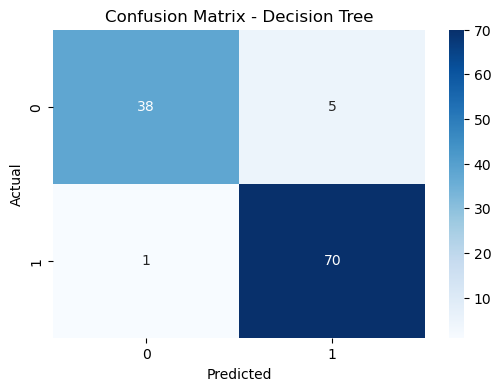

In [25]:
# 7. Save the Model
# We save the trained model to a file so the Streamlit app can load it instantly.
# This avoids retraining the model every time a user interacts with the app.
with open('decision_tree.pkl', 'wb') as f:
    pickle.dump(dt_model, f)
print("Model saved to 'model/decision_tree.pkl'")

# 8. Visualizing Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()